In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset>
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-30T...
    latitude           float64 ...
    longitude          float64 ...
    station_latitude   (station) float64 ...
    station_longitude  (station) float64 ...
Data variables: (12/14)
    u10                (station, valid_time) float32 ...
    v10                (station, valid_time) float32 ...
    d2m                (station, valid_time) float32 ...
    t2m                (station, valid_time) float32 ...
    msl                (station, valid_time) float32 ...
    sst                (station, valid_time) float32 ...
    ...                 ...
    mwd                (station, valid_time) float32 ...
    mwp                (station, valid_time) float32 ...
    swh                (station, valid_

In [3]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")

In [3]:
# Ensure time is sorted (important for derivatives)
ds = ds.sortby("valid_time")

# --- Core helpers (finite differences over hours) ---
def diff_hours(da, hours: int):
    """Finite-difference derivative over 'hours' (value change per hour)."""
    return (da - da.shift(valid_time=hours)) / hours

# --- Wind features ---
u = ds["u10"]
v = ds["v10"]
wind_speed = np.hypot(u, v).rename("wind_speed")

d_wind_1h = diff_hours(wind_speed, 1).rename("d_wind_1h")   # Δwind / 1h
d_wind_6h = diff_hours(wind_speed, 6).rename("d_wind_6h")   # Δwind / 6h

# --- Pressure derivatives (dsp/dt) ---
sp = ds["sp"]
d_sp_1h = diff_hours(sp, 1).rename("d_sp_1h")
d_sp_6h = diff_hours(sp, 6).rename("d_sp_6h")

# --- Tide shifted features ---
tide_lag1h = ds["tide"].shift(valid_time=1).rename("tide_lag1h")
tide_lag6h = ds["tide"].shift(valid_time=6).rename("tide_lag6h")
tide_lag0h = ds["tide"].shift(valid_time=0).rename("tide_lag0h")

# Make sure sorted
ds = ds.sortby("valid_time")

# Pull just tide to a tidy frame
df = ds[["tide"]].to_dataframe().reset_index()
df = df.sort_values(["station", "valid_time"])

# Compute tidal range per station (across all valid_time)
tide_range = (ds["tide"].max(dim="valid_time") - ds["tide"].min(dim="valid_time"))
tide_range = tide_range.rename("tide_range")

# --- Air density (rho_air) ---
# Use sp (Pa) and t2m (K) if available; else fallback to 1.225 kg/m^3
R_d = 287.05  # J kg^-1 K^-1
if "sp" in ds and "t2m" in ds:
    rho_air = (ds["sp"] / (R_d * ds["t2m"])).astype("float32").rename("rho_air")
else:
    rho_air = xr.zeros_like(wind_speed) + 1.225
    rho_air = rho_air.astype("float32").rename("rho_air")

# --- Drag coefficient C_D (Large & Pond style) ---
U = wind_speed
Cd = xr.where(
    U < 11.0,
    1.14e-3,
    xr.where(U <= 25.0, (0.49 + 0.065 * U) * 1e-3, 2.0e-3)
).astype("float32").rename("Cd")

# --- Wind stress components (N/m^2 = Pa) ---
tau_x = (rho_air * Cd * U * u).astype("float32").rename("tau_x")
tau_y = (rho_air * Cd * U * v).astype("float32").rename("tau_y")
tau_mag = (rho_air * Cd * U**2).astype("float32").rename("tau_mag")

# Optional: tendencies (change over 1h/6h), consistent with your diff_hours helper
tau_d1h = diff_hours(tau_mag, 1).astype("float32").rename("d_tau_1h")
tau_d6h = diff_hours(tau_mag, 6).astype("float32").rename("d_tau_6h")

# --- Assemble into one dataset ---
feat_ds = xr.Dataset(
    {
        "wind_speed": wind_speed,
        "d_wind_1h": d_wind_1h,
        "d_wind_6h": d_wind_6h,
        "d_sp_1h": d_sp_1h,
        "d_sp_6h": d_sp_6h,
        "tide_range_12h": tide_range,
        "tide_lag0h": tide_lag0h,
        "tide_lag1h": tide_lag1h,
        "tide_lag6h": tide_lag6h,
        # "d_msl_1h": d_msl_1h,  # uncomment if you computed these
        # "d_msl_6h": d_msl_6h,
        "tau_x": tau_x,
        "tau_y": tau_y,
        "tau_mag": tau_mag,
        "tau_d1h": tau_d1h,
        "tau_d6h": tau_d6h,
    }
)

# Keep original coordinates/attrs
feat_ds = feat_ds.assign_coords(
    station=ds["station"],
    valid_time=ds["valid_time"]
)
for v in feat_ds.data_vars:
    feat_ds[v].attrs.update(ds[v.split("_")[0]].attrs if v.split("_")[0] in ds.data_vars else {})

# Merge features back with original dataset (optional)
ds_engineered = xr.merge([ds, feat_ds])

In [5]:
# exclude target + sea_level + tide from predictors
predictors = [v for v in ds_engineered.data_vars if v not in ["residual", "sea_level", "tide", "longitude", "latitude", "station_longitude", "station_latitude", "station", "valid_time"]]
target = "residual"
df = ds_engineered[predictors + [target]].to_dataframe().reset_index()
df = df.dropna(subset=[target])

# Integrate all factors

In [4]:

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

from functools import lru_cache
import numpy as np
from cartopy.io import shapereader
from shapely.geometry import LineString, MultiLineString
import pyproj

@lru_cache(maxsize=4)
def _coast_segments_arrays(resolution="10m"):
    """
    One-time shapefile read -> flat arrays of segment endpoints and lengths (km).
    Kept in an LRU cache so you don't loop the shapefile every call.
    """
    shp = shapereader.natural_earth(resolution=resolution, category="physical", name="coastline")
    reader = shapereader.Reader(shp)
    geod = pyproj.Geod(ellps="WGS84")

    l1, b1, l2, b2, L = [], [], [], [], []
    for geom in reader.geometries():  # <-- unavoidable once; cached afterwards
        lines = [geom] if isinstance(geom, LineString) else (list(geom.geoms) if isinstance(geom, MultiLineString) else [])
        for ln in lines:
            c = np.asarray(ln.coords, dtype=float)
            if c.shape[0] < 2: continue
            p0, p1 = c[:-1], c[1:]
            az, baz, dist_m = geod.inv(p0[:,0], p0[:,1], p1[:,0], p1[:,1])
            mask = dist_m > 0
            if not np.any(mask): continue
            l1.append(p0[mask,0]); b1.append(p0[mask,1])
            l2.append(p1[mask,0]); b2.append(p1[mask,1])
            L.append(dist_m[mask] / 1000.0)
    l1 = np.concatenate(l1); b1 = np.concatenate(b1)
    l2 = np.concatenate(l2); b2 = np.concatenate(b2)
    L  = np.concatenate(L)
    return l1, b1, l2, b2, L  # arrays (N,)

def _wrap_lon_to_dataset(lon, ds):
    lon_min = float(ds.lon.min()); lon_max = float(ds.lon.max())
    if lon_max > 180:  # dataset in [0,360)
        lon = lon % 360.0
    else:              # dataset in [-180,180)
        lon = ((lon + 180.0) % 360.0) - 180.0
    return lon

def _nearest_1d_idx(vec, x):
    """
    Vectorized nearest-neighbor index for a 1D monotonic vec (asc or desc).
    """
    vec = np.asarray(vec)
    asc = vec[1] >= vec[0]
    if not asc:
        vec_mono = vec[::-1]
        i = np.searchsorted(vec_mono, x, side="left")
        i = len(vec) - i - 1
        iL = np.clip(i, 1, len(vec)-1) - 1
        iR = np.clip(i, 0, len(vec)-1)
    else:
        i = np.searchsorted(vec, x, side="left")
        iL = np.clip(i-1, 0, len(vec)-1)
        iR = np.clip(i,   0, len(vec)-1)
    left  = vec[iL]
    right = vec[iR]
    choose_right = np.abs(right - x) < np.abs(x - left)
    idx = np.where(choose_right, iR, iL)
    return idx

import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 128, W: int = 128) -> xr.Dataset:
    """
    Quick, vectorized resize of a GEBCO tile to (H,W) using xarray's interp.
    Works for all numeric vars defined on (lat, lon). Keeps dask laziness.
    """
    # Build uniform target coords spanning the tile extent (ascending)
    lat0, lat1 = float(ds_tile.lat.min()), float(ds_tile.lat.max())
    lon0, lon1 = float(ds_tile.lon.min()), float(ds_tile.lon.max())
    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    # Interpolate all variables defined on (lat, lon)
    return ds_tile.interp(lat=new_lat, lon=new_lon, method="linear")


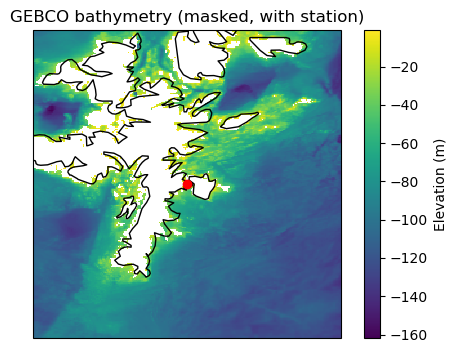

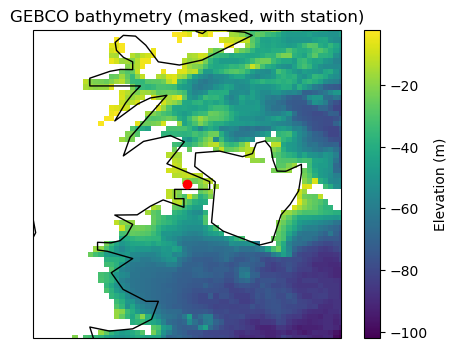

In [5]:
import numpy as np
import xarray as xr

def to_minus180_180(lon_array):
    lon = np.asarray(lon_array, dtype=np.float64)
    return ((lon + 180.0) % 360.0) - 180.0

def extract_square_with_meta(ds, lat, lon, size_deg, station_id=None):
    """
    Extract a size_deg x size_deg box around (lat, lon) and attach
    station metadata as scalar coords.
    """
    half = size_deg / 2.0

    # GEBCO may have either ascending or descending lat; use min/max safely
    lat_min, lat_max = min(lat - half, lat + half), max(lat - half, lat + half)
    lon_min, lon_max = lon - half, lon + half

    tile = ds.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

    # Attach exact station coords (scalar coords, not attributes)
    # These will round-trip cleanly through xarray and are easy to read later.
    tile = tile.assign_coords(
        station_id = ((), -1 if station_id is None else int(station_id)),
        station_latitude  = ((), float(lat)),
        station_longitude = ((), float(lon)),
    )
    return tile


def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()


# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

# Open GEBCO and make sure longitudes are in [-180, 180]
# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])
if "lon" in GEBCO_ds:
    GEBCO_ds = GEBCO_ds.assign_coords(lon=to_minus180_180(GEBCO_ds["lon"].values)).sortby(["lat", "lon"])

# Open sea level/stations and canonicalize station longitudes too
ds_sealevel = xr.open_dataset("/Users/lb962/Documents/GitHub/ESL/data/processed/filtered_GESLA_sea_level.nc")

stations = ds_sealevel["station"].values
lats     = ds_sealevel["latitude"].values
lons     = to_minus180_180(ds_sealevel["longitude"].values)

# Build mapping (lat, lon) -> station_id and unique pairs
latlon_to_station = {(float(la), float(lo)): int(st) for st, la, lo in zip(stations, lats, lons)}
unique_latlon = list(latlon_to_station.keys())
# Desired resolutions (squares)
resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]
results = {f"{r}x{r}": [] for r in resolutions}

for (lat, lon) in unique_latlon:
    stn_id = latlon_to_station[(lat, lon)]
    for size in resolutions:
        key = f"{size}x{size}"
        tile = extract_square_with_meta(GEBCO_ds, lat, lon, size_deg=size, station_id=stn_id)
        results[key].append(tile)
# Example usage:
plot_tile(results["1.0x1.0"][0])
plot_tile(results["0.25x0.25"][0])

In [6]:
# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (128, 128), f"{k} -> {shp}, expected (128, 128)"

# Train MAE

In [7]:

def random_coastal_points_GEBCO_vec(
    GEBCO_ds,
    n_points=200,
    margin_km=20,
    seed=0,
    resolution="10m",
    dedup_km=5,
    require_valid_elevation=False,
    oversample=50  # try 30–100 depending on filters/dedup
):
    """
    Vectorized coastal sampler (no per-point loops).
    Returns a list of (lat, lon) length n_points.
    """
    rng = np.random.default_rng(seed)
    geod = pyproj.Geod(ellps="WGS84")

    # --- 1) coastline segments as arrays (cached) ---
    s_l1, s_b1, s_l2, s_b2, s_L = _coast_segments_arrays(resolution=resolution)
    probs = s_L / s_L.sum()
    N = n_points * oversample

    # --- 2) sample segments & interpolate points in one go ---
    seg_idx = rng.choice(s_L.size, size=N, p=probs)
    t = rng.random(N)
    # shortest-longitude interpolation
    dlon = ((s_l2[seg_idx] - s_l1[seg_idx] + 180.0) % 360.0) - 180.0
    lon0 = s_l1[seg_idx] + t * dlon
    lat0 = s_b1[seg_idx] + t * (s_b2[seg_idx] - s_b1[seg_idx])
    lon0 = ((lon0 + 180.0) % 360.0) - 180.0

    # --- 3) jitter by margin_km (vectorized geodesic forward) ---
    if margin_km and margin_km > 0:
        az = rng.uniform(0.0, 360.0, size=N)
        r  = margin_km * np.sqrt(rng.random(N))  # area-preserving radial pick
        lon1, lat1, _ = geod.fwd(lon0, lat0, az, r * 1000.0)
    else:
        lon1, lat1 = lon0, lat0

    # --- 4) bounds filter (vectorized) ---
    lat1 = lat1.astype(float); lon1 = lon1.astype(float)
    inside = (float(GEBCO_ds.lat.min()) <= lat1) & (lat1 <= float(GEBCO_ds.lat.max()))
    lon1g = _wrap_lon_to_dataset(lon1, GEBCO_ds)
    inside &= (float(GEBCO_ds.lon.min()) <= lon1g) & (lon1g <= float(GEBCO_ds.lon.max()))
    inside &= (np.abs(lat1) <= 85.0)

    # --- 5) optional elevation-validity filter (vectorized nearest NN) ---
    if require_valid_elevation:
        lat_vals = np.asarray(GEBCO_ds.lat.values)
        lon_vals = np.asarray(GEBCO_ds.lon.values)
        ii = _nearest_1d_idx(lat_vals, lat1)
        jj = _nearest_1d_idx(lon_vals, lon1g)
        elev = GEBCO_ds["elevation"].values[ii, jj]
        inside &= np.isfinite(elev)

    # --- 6) deduplicate by ~dedup_km grid (vectorized) ---
    lat_step = dedup_km / 111.0
    lon_step = dedup_km / (111.0 * np.maximum(1e-6, np.cos(np.deg2rad(lat1))))
    lat_q = np.round(lat1 / lat_step).astype(np.int64)
    lon_q = np.round(lon1 / lon_step).astype(np.int64)

    keep = inside
    key = np.stack([lat_q, lon_q], axis=1)
    # unique while keeping first occurrence order
    uniq_key, first_idx = np.unique(key[keep], axis=0, return_index=True)
    order = np.argsort(first_idx)
    sel_idx = np.flatnonzero(keep)[first_idx[order]]

    # --- 7) take first n_points (clip if fewer) ---
    sel_idx = sel_idx[:n_points]
    if sel_idx.size < n_points:
        raise RuntimeError(
            f"Only {sel_idx.size}/{n_points} unique points after filters. "
            f"Increase oversample, reduce dedup_km, or set require_valid_elevation=False."
        )

    return list(zip(lat1[sel_idx].tolist(), lon1[sel_idx].tolist()))
# Vectorized sampler
random_points = random_coastal_points_GEBCO_vec(
    GEBCO_ds,
    n_points=1000,
    margin_km=10,
    seed=2025,
    resolution="10m",
    dedup_km=5,
    require_valid_elevation=True,
    oversample=60,   # bump if you often get < n_points after filters
)

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]

# Initialize results dict
results_train = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}
i = 0
for (lat, lon) in random_points:
    stn_id +=1
    for size in resolutions:
        key = f"{size}x{size}"
        tile = extract_square_with_meta(GEBCO_ds, lat, lon, size_deg=size, station_id=stn_id)
        results_train[key].append(tile)

In [8]:
# --- apply to every tile in your dict ---
rand_results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results_train.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in rand_results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (128, 128), f"{k} -> {shp}, expected (128, 128)"

In [9]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

def try_collect_tiles_from_results():
    """Collect 2D elevation arrays from results[...] xarray tiles."""
    if "results" not in globals():
        raise NameError("`results` not found in globals.")
    key = "1x1" if "1x1" in results and results["1x1"] else next(iter(results.keys()))
    tiles = []
    for ds in results[key]:
        if "elevation" not in ds:
            continue
        arr = np.array(ds["elevation"].values)
        if arr.ndim == 2:
            tiles.append(arr.astype(np.float32))
    if not tiles:
        raise ValueError("No usable 2D elevation arrays found in results.")
    return tiles, f"from results['{key}'] ({len(tiles)} tiles)"

def make_synthetic_tiles(n=64, h=64, w=64, seed=0):
    """Synthetic bathymetry-like tiles with NaNs on 'land' (> -0.5 m)."""
    rng = np.random.default_rng(seed)
    tiles = []
    y = np.linspace(0, 3*np.pi, h)
    x = np.linspace(0, 3*np.pi, w)
    Y, X = np.meshgrid(y, x, indexing='ij')
    for _ in range(n):
        base = np.sin(X) * np.cos(Y)
        base += 0.3 * np.sin(3*X + 0.2) * np.cos(2*Y - 0.5)
        base += 0.1 * rng.normal(size=(h, w))
        elev = -1000 + 800 * base
        elev = np.where(elev <= -0.5, elev, np.nan)
        tiles.append(elev.astype(np.float32))
    return tiles, f"synthetic ({n} tiles, {h}x{w})"

def resize_bilinear(img, new_h, new_w):
    """Vectorized bilinear resize (2D array), NaNs interpolate too."""
    H, W = img.shape
    if H == new_h and W == new_w:
        return img.copy()
    yi = np.linspace(0, H - 1, new_h)
    xi = np.linspace(0, W - 1, new_w)
    y0 = np.floor(yi).astype(int); y1 = np.minimum(y0 + 1, H - 1)
    x0 = np.floor(xi).astype(int); x1 = np.minimum(x0 + 1, W - 1)
    wy = (yi - y0)[:, None]
    wx = (xi - x0)[None, :]
    I00 = img[y0[:, None], x0[None, :]]
    I01 = img[y0[:, None], x1[None, :]]
    I10 = img[y1[:, None], x0[None, :]]
    I11 = img[y1[:, None], x1[None, :]]
    return (1 - wy) * ((1 - wx) * I00 + wx * I01) + wy * ((1 - wx) * I10 + wx * I11)

class TileDataset(torch.utils.data.Dataset):
    def __init__(self, tiles, H=32, W=32, mask_ratio=0.75, seed=42):
        self.H, self.W = H, W
        self.mask_ratio = mask_ratio
        self.rng = np.random.default_rng(seed)

        X_list, V_list = [], []
        for img in tiles:
            img32 = resize_bilinear(np.asarray(img, dtype=np.float32), H, W)
            valid = ~np.isnan(img32)
            x = np.where(valid, img32, 0.0).astype(np.float32)
            X_list.append(x)
            V_list.append(valid.astype(np.float32))

        X = np.stack(X_list, 0)
        V = np.stack(V_list, 0)

        valid_sum = V.sum()
        mean = float((X * V).sum() / valid_sum)
        std = float(np.sqrt((((X - mean) * V) ** 2).sum() / valid_sum))
        X = (X - mean) / (std + 1e-8)

        self.X = torch.from_numpy(X)
        self.V = torch.from_numpy(V)
        self.N = self.X.shape[0]
        self.D = H * W

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        x = self.X[idx]        # (H, W)
        v = self.V[idx]        # (H, W)
        m = (torch.rand_like(v) < self.mask_ratio).float()
        return x.view(-1), v.view(-1), m.view(-1)


class TinyMAE(nn.Module):
    def __init__(self, D, hidden=128):
        super().__init__()
        self.enc = nn.Linear(D, hidden)
        self.act = nn.ReLU()
        self.dec = nn.Linear(hidden, D)

    # ----- TRAINING PATH (keeps gradients) -----
    def forward(self, x_in):
        z = self.forward_encoder(x_in)  # no torch.no_grad here
        y = self.forward_decoder(z)     # no torch.no_grad here
        return y

    def forward_encoder(self, x_in):
        # returns latent (B, hidden) with grads
        return self.act(self.enc(x_in))

    def forward_decoder(self, z):
        # returns reconstruction (B, D) with grads
        return self.dec(z)

    # ----- INFERENCE HELPERS (no grads) -----
    def encode_nograd(self, x_in):
        with torch.no_grad():
            return self.forward_encoder(x_in)

    def decode_nograd(self, z):
        with torch.no_grad():
            return self.forward_decoder(z)
        
def train_mae(
    tiles, H=32, W=32, mask_ratio=0.75,
    hidden=128, batch_size=32, steps=200,
    lr=1e-3, weight_decay=1e-4, seed=0, device="cpu"
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    ds = TileDataset(tiles, H=H, W=W, mask_ratio=mask_ratio, seed=seed)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    model = TinyMAE(D=H*W, hidden=hidden).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    it = iter(loader)
    losses = []

    for step in range(1, steps + 1):
        try:
            x, v, m = next(it)
        except StopIteration:
            it = iter(loader)
            x, v, m = next(it)

        x, v, m = x.to(device), v.to(device), m.to(device)
        xin = x * (1.0 - m)
        y = model(xin)

        M = m * v
        denom = M.sum().clamp_min(1e-8)
        loss = ((y - x) ** 2 * M).sum() / denom

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        losses.append(loss.item())

    return losses, model
# Train on ALL resolutions at once
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict

# --- tiny NaN-aware resizer to (H,W) ---
def _resize_to_hw(arr2d: np.ndarray, H: int, W: int):
    assert arr2d.ndim == 2
    msk = np.isfinite(arr2d)
    if not msk.any():
        return None
    med = np.nanmedian(arr2d)
    arr_filled = np.where(msk, arr2d, med).astype(np.float32)

    val = np.asarray(Image.fromarray(arr_filled).resize((W, H), Image.BILINEAR), dtype=np.float32)
    msk_r = np.asarray(Image.fromarray((msk.astype(np.uint8)*255)).resize((W, H), Image.NEAREST)) > 0
    return np.where(msk_r, val, np.nan).astype(np.float32)

def collect_all_res_tiles(results, H, W, var="elevation"):
    """Merge tiles from ALL resolution keys into one list, resizing if needed."""
    tiles, counts = [], defaultdict(int)
    for key, lst in results.items():
        for i, ds in enumerate(lst):
            if var not in ds:
                continue
            arr = np.asarray(ds[var].values, dtype=np.float32)
            if arr.ndim != 2:
                continue
            if arr.shape != (H, W):
                arr = _resize_to_hw(arr, H, W)
                if arr is None:
                    continue
            tiles.append(arr)
            counts[key] += 1
    if not tiles:
        raise ValueError("No usable tiles found across resolutions.")
    print("Per-resolution counts:", dict(counts), "| total:", len(tiles))
    return tiles


In [ ]:

# ---------------- Hyperparams ----------------
H, W = 128, 128
mask_ratio = 0.75
hidden = 128
batch_size = 8
steps = 1000
lr = 1e-4
weight_decay = 1e-4
device = "cpu"

# -------------- Collect & Train --------------
all_tiles = collect_all_res_tiles(rand_results_128[:1000], H=H, W=W, var="elevation")

print(f"Training ONE model on {len(all_tiles)} mixed-resolution tiles...")
losses, model = train_mae(
    all_tiles,
    H=H, W=W,
    mask_ratio=mask_ratio,
    hidden=hidden,
    batch_size=batch_size,
    steps=steps,
    lr=lr,
    weight_decay=weight_decay,
    device=device,
)
print(f"Final loss: {losses[-1]:.6f}")

# ----------------- Plot loss -----------------
plt.figure(figsize=(7,4))
plt.plot(losses, label="all resolutions (mixed)")
plt.xlabel("Training step"); plt.ylabel("Masked MSE loss")
plt.title("MAE training loss (all resolutions together)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

Per-resolution counts: {'0.1x0.1': 1000, '0.25x0.25': 1000, '1.0x1.0': 1000, '3.0x3.0': 1000, '10.0x10.0': 1000} | total: 5000
Training ONE model on 5000 mixed-resolution tiles...


: 

In [ ]:
# ---- config ----
H = 128
W = 128
device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval().to(device)

TinyMAE(
  (enc): Linear(in_features=16384, out_features=128, bias=True)
  (act): ReLU()
  (dec): Linear(in_features=128, out_features=16384, bias=True)
)

In [ ]:
def _resize_bilinear(img, new_h, new_w):
    H0, W0 = img.shape
    if (H0, W0) == (new_h, new_w):
        return img.copy()
    # PIL for simplicity/consistency with earlier code
    return np.asarray(Image.fromarray(img).resize((new_w, new_h), Image.BILINEAR), dtype=np.float32)

def compute_stats_from_tiles(tiles, H, W):
    """Compute valid-pixel mean/std exactly like TileDataset did."""
    valid_sum = 0.0
    sum_ = 0.0
    sqsum_ = 0.0
    for t in tiles:
        arr = np.asarray(t, dtype=np.float32)
        arr = _resize_bilinear(arr, H, W)
        v = np.isfinite(arr)
        x = np.where(v, arr, 0.0)
        valid_sum += v.sum()
        sum_ += float((x * v).sum())
        sqsum_ += float(((x ** 2) * v).sum())
    if valid_sum == 0:
        raise ValueError("No valid pixels found to compute stats.")
    mean = sum_ / valid_sum
    var = sqsum_ / valid_sum - mean * mean
    std = float(np.sqrt(max(var, 1e-12)))
    return float(mean), float(std)


# Prefer to compute mean/std from the same data used to train.
try:
    _ = all_tiles  # if available from earlier
    mean_train, std_train = compute_stats_from_tiles(all_tiles, H, W)

except NameError:
    # Fallback: compute stats from results_128 itself
    # (slight domain shift vs training if the distributions differ)
    tmp_tiles = []
    for key, lst in rand_results_128.items():
        for ds in lst:
            if "elevation" in ds:
                tmp_tiles.append(np.asarray(ds["elevation"].values, dtype=np.float32))
    mean_train, std_train = compute_stats_from_tiles(tmp_tiles, H, W)

In [ ]:

def preprocess_tile(arr2d, H, W, mean, std):
    """Resize, zero-fill NaNs, normalize like training; return (D,) float32."""
    a = np.asarray(arr2d, dtype=np.float32)
    a = _resize_bilinear(a, H, W)
    v = np.isfinite(a)
    x = np.where(v, a, 0.0).astype(np.float32)
    x = (x - mean) / (std + 1e-8)
    return x.reshape(-1)

@torch.no_grad()
def encode_batch(flat_batch_2d):
    """
    flat_batch_2d: (B, D) numpy or torch
    returns (B, hidden) L2-normalized torch tensor on CPU
    """
    if isinstance(flat_batch_2d, np.ndarray):
        xb = torch.from_numpy(flat_batch_2d)
    else:
        xb = flat_batch_2d
    xb = xb.to(device, dtype=torch.float32)
    # Use encoder path (keeps grads off because we're under no_grad)
    if hasattr(model, "forward_encoder"):
        z = model.forward_encoder(xb)
    else:
        # TinyMAE forward is decode; we want enc->act
        z = model.act(model.enc(xb))
    z = torch.nn.functional.normalize(z, dim=1)
    return z.cpu()

# ---------- encode per location ----------
features_by_location = {}
names_by_location = {}

for loc_key, ds_list in results_128.items():
    flat_vecs = []
    names = []
    for i, ds in enumerate(ds_list):
        if "elevation" not in ds:
            continue
        arr = ds["elevation"].values
        if arr.ndim != 2:
            continue
        flat = preprocess_tile(arr, H, W, mean_train, std_train)
        flat_vecs.append(flat)
        # make a readable name; adjust if ds has an id you prefer
        names.append(f"{loc_key}_tile{i:04d}")
    if not flat_vecs:
        continue

    X = np.stack(flat_vecs, axis=0)        # (N, D)
    Z = encode_batch(X)                    # (N, hidden) on CPU
    features_by_location[loc_key] = Z.numpy()
    names_by_location[loc_key] = names

In [ ]:
import numpy as np

def to_minus180_180(lon):
    lon = float(lon)
    return ((lon + 180.0) % 360.0) - 180.0

def extract_station_coords(ds):
    """
    Prefer scalar coords 'station_latitude'/'station_longitude' if present.
    Fallback to 'latitude'/'longitude' variables, else mean of grid coords.
    Always returns (lat, lon) with lon in [-180,180].
    """
    # 1) scalar coords saved earlier
    for lat_key, lon_key in [
        ("station_latitude", "station_longitude"),
        ("latitude", "longitude"),
    ]:
        if lat_key in ds.coords and lon_key in ds.coords:
            lat = float(np.asarray(ds.coords[lat_key]).item())
            lon = float(np.asarray(ds.coords[lon_key]).item())
            return float(lat), to_minus180_180(lon)

        if lat_key in ds and lon_key in ds:
            # 0-dim data variables
            lat_arr = np.asarray(ds[lat_key].values)
            lon_arr = np.asarray(ds[lon_key].values)
            if lat_arr.ndim == 0 and lon_arr.ndim == 0:
                lat = float(lat_arr.item()); lon = float(lon_arr.item())
                return float(lat), to_minus180_180(lon)

    # 2) fallback: mean of grid coords
    if "lat" in ds.coords and "lon" in ds.coords:
        lat = float(np.mean(ds.coords["lat"].values))
        lon = float(np.mean(ds.coords["lon"].values))
        return float(lat), to_minus180_180(lon)

    raise ValueError("Could not find station or grid coordinates in ds.")

# ---------- encode per location + KEEP METADATA ----------
features_by_location = {}
names_by_location = {}
coords_by_location = {}
meta_by_location = {}          # NEW: keeps per-tile meta, including exact station coords

for loc_key, ds_list in results_128.items():
    flat_vecs, names, coords, metas = [], [], [], []

    for i, ds in enumerate(ds_list):
        if "elevation" not in ds:
            continue
        arr = ds["elevation"].values
        if arr.ndim != 2:
            continue

        # preprocess -> flatten to D
        flat = preprocess_tile(arr, H, W, mean_train, std_train)
        flat_vecs.append(flat)

        # readable tile ID
        name = f"{loc_key}_tile{i:04d}"
        names.append(name)

        # ---- exact station coords (preferred) ----
        sta_lat, sta_lon = extract_station_coords(ds)
        coords.append((sta_lat, sta_lon))

        # keep extra meta (optional: station_id if present)
        stn_id = None
        for key in ("station_id", "id", "station"):
            if key in ds.coords and np.asarray(ds.coords[key]).ndim == 0:
                stn_id = int(np.asarray(ds.coords[key]).item())
                break
            if key in ds and np.asarray(ds[key]).ndim == 0:
                stn_id = int(np.asarray(ds[key]).item())
                break

        metas.append({
            "tile_name": name,
            "station_id": stn_id,
            "station_latitude": sta_lat,
            "station_longitude": sta_lon,
            "resolution_key": loc_key,
        })

    if not flat_vecs:
        continue

    # encode batch -> (N, hidden)
    X = np.stack(flat_vecs, axis=0)
    Z = encode_batch(X)

    features_by_location[loc_key] = Z.numpy()
    names_by_location[loc_key] = names
    coords_by_location[loc_key] = np.array(coords, dtype=np.float64)  # (N,2) lat, lon
    meta_by_location[loc_key] = metas

In [ ]:
import numpy as np
import pandas as pd
import re
from collections import defaultdict

# ---------- helpers ----------
def to_minus180_180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

def _label_from_key(k):
    """
    Turn resolution key into a clean label:
      - "0.25x0.25" -> "0.25"
      - "1x1"       -> "1"
      - 0.1         -> "0.1"
    """
    s = str(k)
    m = re.match(r'^\s*([0-9]*\.?[0-9]+)\s*x', s)
    if m:
        val = float(m.group(1))
    else:
        # if the key itself is numeric-like
        try:
            val = float(s)
        except Exception:
            # fallback: keep raw
            return s.strip()
    # format without trailing zeros (1 -> "1", 0.10 -> "0.1")
    return f"{val:g}"

PREC = 6  # rounding precision for merge keys

def merge_encoded_with_meta(df, features_by_location, meta_by_location,
                            lat_col="station_latitude", lon_col="station_longitude",
                            prec=PREC):
    df_out = df.copy()

    # Build merge keys on DF
    if lat_col not in df_out.columns or lon_col not in df_out.columns:
        raise KeyError(f"Expected columns '{lat_col}' and '{lon_col}' in df.")
    df_out["lat_key"] = df_out[lat_col].astype(float).round(prec)
    df_out["lon_key"] = to_minus180_180(df_out[lon_col].astype(float).values).round(prec)

    # Pre-create encoded columns for all resolutions so they always exist
    created_cols = []
    for loc_key in features_by_location.keys():
        lab = _label_from_key(loc_key)
        col = f"encoded_{lab}"
        if col not in df_out.columns:
            df_out[col] = np.nan
        created_cols.append(col)

    # Merge each resolution
    for loc_key, feats in features_by_location.items():
        metas = meta_by_location[loc_key]
        lab = _label_from_key(loc_key)
        col = f"encoded_{lab}"

        # average duplicates per (lat,lon)
        sums = {}
        cnts = {}
        for i, meta in enumerate(metas):
            la = float(meta["station_latitude"])
            lo = to_minus180_180(float(meta["station_longitude"]))
            la_k = round(la, prec)
            lo_k = round(lo, prec)
            key = (la_k, lo_k)
            vec = np.asarray(feats[i], dtype=np.float32)
            if key in sums:
                sums[key] += vec
                cnts[key] += 1
            else:
                sums[key] = vec.copy()
                cnts[key] = 1

        if not sums:
            # nothing to merge for this resolution; continue
            continue

        rows = [{"lat_key": k[0], "lon_key": k[1], col: sums[k] / cnts[k]} for k in sums]
        df_res = pd.DataFrame(rows)

        df_out = df_out.merge(df_res, how="left", on=["lat_key", "lon_key"])

        # If merge created a new column with suffix because it already existed,
        # coalesce it back into the intended column name.
        if f"{col}_x" in df_out.columns and f"{col}_y" in df_out.columns:
            df_out[col] = df_out[f"{col}_y"].combine_first(df_out[f"{col}_x"])
            df_out = df_out.drop(columns=[f"{col}_x", f"{col}_y"])
        elif f"{col}_y" in df_out.columns:
            df_out[col] = df_out[f"{col}_y"]
            df_out = df_out.drop(columns=[f"{col}_y"])

    # Drop helper keys
    df_out = df_out.drop(columns=["lat_key", "lon_key"])

    # ---- summary ----
    print("Encoded columns created:", sorted([c for c in df_out.columns if c.startswith("encoded_")]))
    for c in sorted([c for c in df_out.columns if c.startswith("encoded_")]):
        matched = df_out[c].apply(lambda v: isinstance(v, (np.ndarray, list))).sum()
        print(f"{c}: matched {matched} / {len(df_out)} rows")

    return df_out

# ---- run it ----
df_merged = merge_encoded_with_meta(
    df,
    features_by_location=features_by_location,
    meta_by_location=meta_by_location,
    lat_col="station_latitude",
    lon_col="station_longitude",
    prec=6
)


Encoded columns created: ['encoded_0.1', 'encoded_0.25', 'encoded_1', 'encoded_10', 'encoded_3']
encoded_0.1: matched 3412604 / 3412604 rows
encoded_0.25: matched 3412604 / 3412604 rows
encoded_1: matched 3412604 / 3412604 rows
encoded_10: matched 3412604 / 3412604 rows
encoded_3: matched 3412604 / 3412604 rows


In [ ]:
df_merged.columns

Index(['station', 'valid_time', 'u10', 'v10', 'd2m', 't2m', 'msl', 'sst', 'sp',
       'tp', 'mwd', 'mwp', 'swh', 'wind_speed', 'd_wind_1h', 'd_wind_6h',
       'd_sp_1h', 'd_sp_6h', 'tide_range_12h', 'tide_lag0h', 'tide_lag1h',
       'tide_lag6h', 'tau_x', 'tau_y', 'tau_mag', 'tau_d1h', 'tau_d6h',
       'residual', 'latitude', 'longitude', 'station_latitude',
       'station_longitude', 'encoded_0.1', 'encoded_0.25', 'encoded_1',
       'encoded_3', 'encoded_10'],
      dtype='object')

In [ ]:
# exclude target + sea_level + tide from predictors
predictors = [v for v in df_merged.columns if v not in ["residual", "sea_level", "tide", "longitude", "latitude", "station_longitude", "station_latitude", "station", "valid_time"]]
target = "residual"

df_train = df_merged[predictors + [target]].dropna(subset=[target])

# train model

<Axes: >

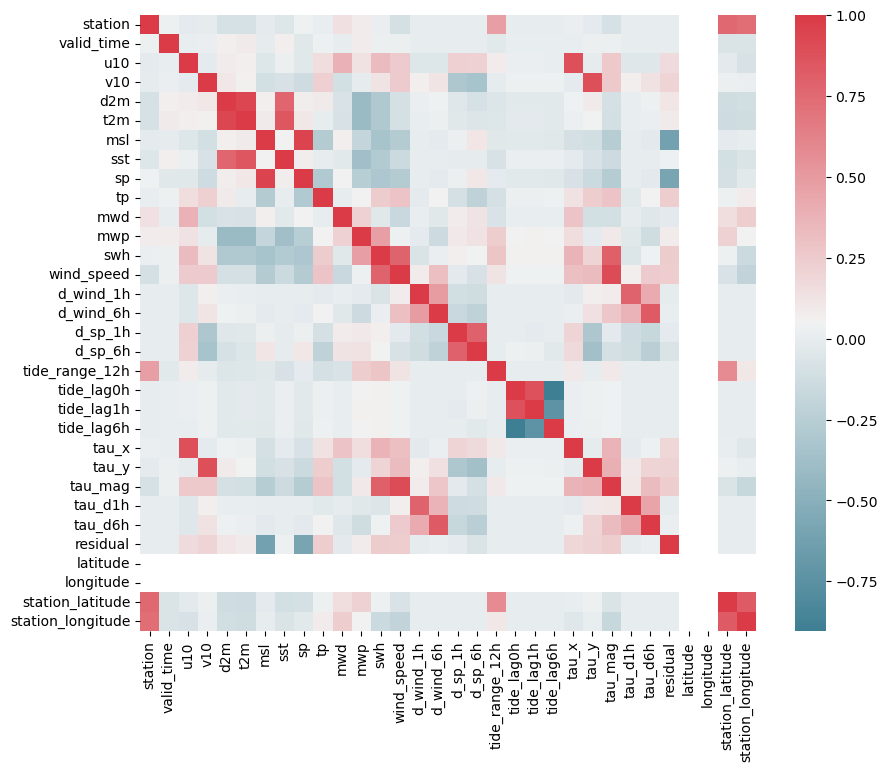

In [ ]:
import seaborn as sns
# run correlation matrix and plot
f, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, mask=np.zeros_like(corr),
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            square=True, ax=ax)

In [ ]:
df_train["encoded_0.1"][0].flatten().shape

(128,)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
RANDOM_SEED=1
def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted(df_merged["station"].unique()))
perm = rng.permutation(stations)

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.10 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = df_merged["station"].isin(train_stn)
m_val   = df_merged["station"].isin(val_stn)
m_test  = df_merged["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train = df_merged.loc[m_train, X_cols], df_merged.loc[m_train, target]
X_val,   y_val   = df_merged.loc[m_val,   X_cols], df_merged.loc[m_val,   target]
X_test,  y_test  = df_merged.loc[m_test,  X_cols], df_merged.loc[m_test,  target]

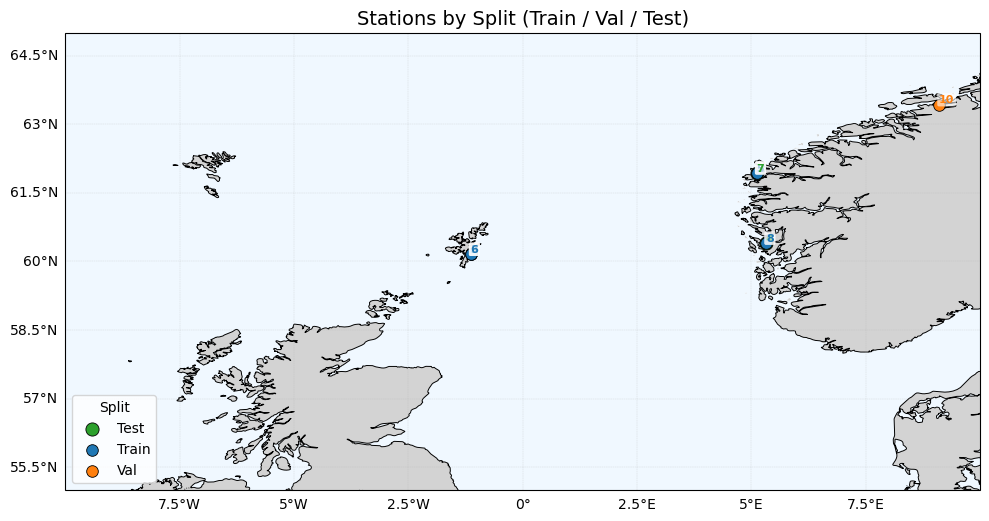

In [ ]:
# pip install cartopy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Unique stations with coordinates
st_meta = (
    df[["station", "station_latitude", "station_longitude"]]
    .dropna(subset=["station_latitude", "station_longitude"])
    .drop_duplicates(subset=["station"])
    .sort_values("station")
    .reset_index(drop=True)
)

# 2) Add split label
def split_label(s):
    if s in train_stn: return "train"
    if s in val_stn:   return "val"
    if s in test_stn:  return "test"
    return "unknown"

st_meta["split"] = st_meta["station"].apply(split_label)

# 3) Map setup
lon_min, lon_max = st_meta["station_longitude"].min(), st_meta["station_longitude"].max()
lat_min, lat_max = st_meta["station_latitude"].min(),  st_meta["station_latitude"].max()

# pad the extent a bit
d_lon = (lon_max - lon_min) or 1.0
d_lat = (lat_max - lat_min) or 1.0
pad = 0.25
#extent = [lon_min - pad*d_lon, lon_max + pad*d_lon,
      #    lat_min - pad*d_lat, lat_max + pad*d_lat]
extent = [-10, 10,
          65, 55]

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)

# basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 4) Plot by split
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "unknown": "gray"}
sizes  = {"train": 70, "val": 70, "test": 90, "unknown": 60}  # make test a bit bigger

for split, df_split in st_meta.groupby("split"):
    ax.scatter(
        df_split["station_longitude"], df_split["station_latitude"],
        s=sizes.get(split, 70),
        color=colors.get(split, "gray"),
        edgecolor="k",
        linewidth=0.6,
        transform=proj,
        zorder=5,
        label=split.capitalize()
    )

# 5) Optional: label station IDs
label_points = True
if label_points:
    for _, r in st_meta.iterrows():
        ax.text(
            r["station_longitude"], r["station_latitude"],
            f'{int(r["station"])}',
            transform=proj,
            fontsize=8, weight="bold",
            ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6),
            zorder=6,
            color=colors.get(r["split"], "black")
        )

# legend & title
handles, labels = ax.get_legend_handles_labels()
# deduplicate legend entries
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower left", title="Split")
plt.title("Stations by Split (Train / Val / Test)", fontsize=14)
plt.tight_layout()
plt.savefig("station_split_map.png", dpi=150)
plt.show()